In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/PARK7/pS47/'

In [33]:
# Calculate distances

# lysine residues to analyse
resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']
chains = ['A','B','B','A']

nsims=3

for i in range(1,nsims+1):
    
    print('Sim {}'.format(i))
    
    # load traj
    u = md.Universe(path+"sim{}/processed.pdb".format(i),path+"sim{}/fit.xtc".format(i))
    
    # atom selections
    sp2 = u.select_atoms('segid A and resname SP2 and name P')
    
    for rn,resi,at,CHAINID in zip(resnames,resids,atoms,chains):
        
        l = u.select_atoms('segid {} and resid {} and name {}'.format(CHAINID,resi,at))
        
        # calculate distances
        dist = []
        
        for frame in range(len(u.trajectory)):
            
            u.trajectory[frame]
            
            d = MDAnalysis.analysis.distances.dist(sp2,l)[2][0]
            
            dist.append(d)
            
        dist = np.array(dist)
        
        np.savetxt(path+"sim{}/{}{}{}_chainA_pS47_distance.txt".format(i,rn,resi,at),dist)
        
    
print('done')

Sim 1
Sim 2
Sim 3
done


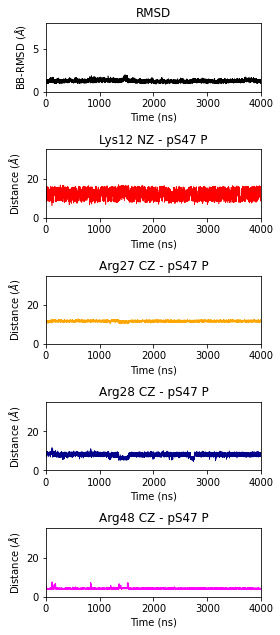

In [34]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=1

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainA_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainA_pS47_SP2_P_distances_sim{}.png'.format(sim))



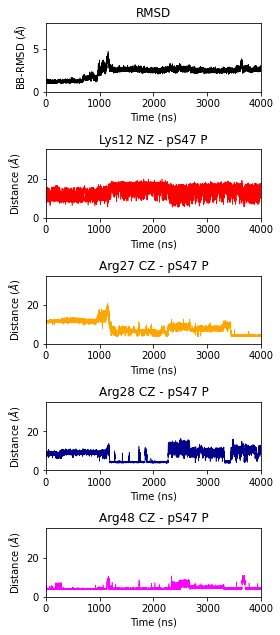

In [35]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=2

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainA_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainA_pS47_SP2_P_distances_sim{}.png'.format(sim))




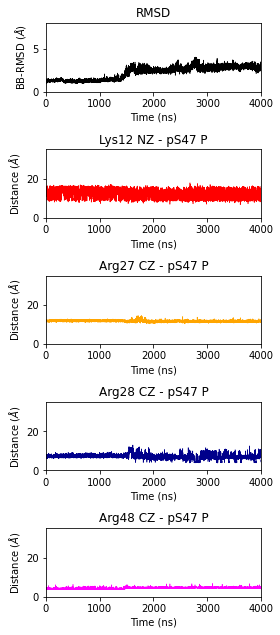

In [36]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=3

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainA_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainA_pS47_SP2_P_distances_sim{}.png'.format(sim))



In [45]:
# Calculate distances

# lysine residues to analyse
resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']
chains = ['B','A','A','B']

nsims=3

for i in range(1,nsims+1):
    
    print('Sim {}'.format(i))
    
    # load traj
    u = md.Universe(path+"sim{}/processed.pdb".format(i),path+"sim{}/fit.xtc".format(i))
    
    # atom selections
    sp2 = u.select_atoms('segid B and resname SP2 and name P')
    
    for rn,resi,at,CHAINID in zip(resnames,resids,atoms,chains):
        
        l = u.select_atoms('segid {} and resid {} and name {}'.format(CHAINID,resi,at))
        
        # calculate distances
        dist = []
        
        for frame in range(len(u.trajectory)):
            
            u.trajectory[frame]
            
            d = MDAnalysis.analysis.distances.dist(sp2,l)[2][0]
            
            dist.append(d)
            
        dist = np.array(dist)
        
        np.savetxt(path+"sim{}/{}{}{}_chainB_pS47_distance.txt".format(i,rn,resi,at),dist)
        
    
print('done')

Sim 1
Sim 2
Sim 3
done


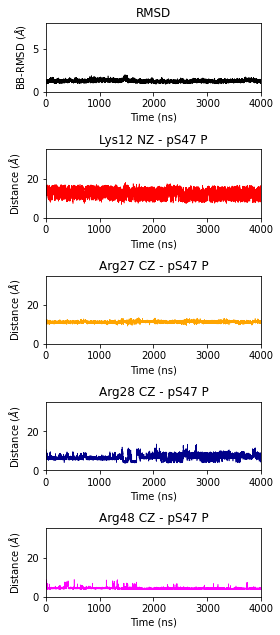

In [46]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=1

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainB_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainB_pS47_SP2_P_distances_sim{}.png'.format(sim))




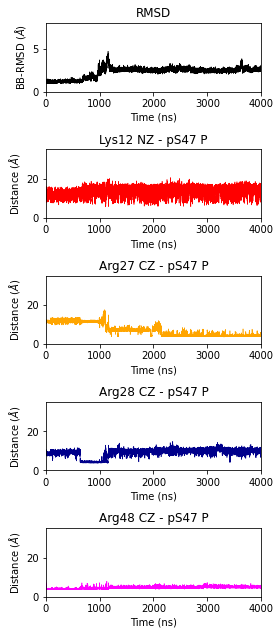

In [47]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=2

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainB_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainB_pS47_SP2_P_distances_sim{}.png'.format(sim))



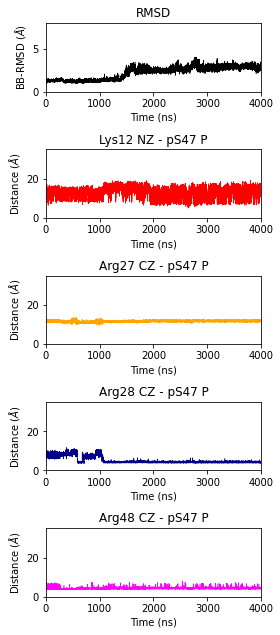

In [48]:

ymax = 35
ymax_rmsd = 8

resnames = ['Lys','Arg','Arg','Arg']
resids = [12,27,28,48]
atoms = ['NZ','CZ','CZ','CZ']

sim=3

plt.figure(figsize = (4,12))

colors = ['red','orange','darkblue','magenta','lightblue','purple']

vals = []

dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
rmsd = dat[:,1]*10 # convert to Angstrom
time = dat[:,0]/1000 # convert to nanoseconds

p=1

# three more panels
plt.subplot(7,1,p)
plt.title('RMSD')
plt.plot(time,rmsd,linewidth = 0.6,color = 'black')
plt.xlabel('Time (ns)')
plt.ylabel('BB-RMSD ($\\AA$)')
plt.ylim(0,ymax_rmsd)
plt.xlim(0,np.max(time))

for rn,resi,at,c in zip(resnames,resids,atoms,colors):
    p+=1
    dist = np.loadtxt(path+"sim{}/{}{}{}_chainB_pS47_distance.txt".format(sim,rn,resi,at))
    
    dat = np.loadtxt(path+"sim{}/rmsd_BB.xvg".format(sim),skiprows=18)
    
    rmsd = dat[:,1]*10 # convert to Angstrom
    time = dat[:,0]/1000 # convert to nanoseconds

    # three more panels
    plt.subplot(7,1,p)
    plt.plot(time,dist,color = c,linewidth = 0.6)
    plt.title('{}{} {} - pS47 P'.format(rn,resi,at))
    plt.ylim(0,ymax)
    plt.xlim(0,np.max(time))

    
    plt.xlabel('Time (ns)')
    plt.ylabel('Distance ($\\AA$)')


plt.tight_layout()
plt.savefig('chainB_pS47_SP2_P_distances_sim{}.png'.format(sim))


